In [ ]:
from typing import Literal
import ismrmrd
import rtoml
import os
from scipy.io import loadmat
from scipy.sparse.linalg import svds
import scipy as sp
from scipy.signal import savgol_filter
import numpy as np
import mrdhelper
import pilottone as pt
from pilottone.pt import extract_triggers
from pilottone.signal import angle_dependant_filtering
import matplotlib.pyplot as plt

from pilottone_ecg_jitter import pt_ecg_jitter
%matplotlib widget

def extract_raw_pt(ksp_measured: np.ndarray, kx: np.ndarray, ky: np.ndarray,
                    n_unique_angles: int, acq: ismrmrd.Acquisition, 
                    f_diff: float, df: float, dt: float, method: Literal['sine', 'wPCA'] = 'sine', freq_correction: bool = True) -> tuple[np.ndarray, np.ndarray]:
    
    n_acq = ksp_measured.shape[1]
    # ================================
    # Demodulate any shifts
    # ================================
    phase_mod_rads = pt.calc_fovshift_phase(kx, ky, acq)
    phase_mod_rads = [phase_mod_rads[:,ii%n_unique_angles] for ii in range(n_acq)]
    phase_mod_rads = np.array(phase_mod_rads)[:, :].transpose()[:,:,None]

    # Apply the negative of the phase
    ksp_measured_ = ksp_measured*phase_mod_rads

    if freq_correction:
        fcorrmin = pt.find_freq_qifft(ksp_measured_[:,:,:], df, f_diff, 3e3, 4, (2))
    else:
        fcorrmin = 0

    ksp_window = np.ones(ksp_measured_.shape[0])
    ksp_measured_ = ksp_measured_*ksp_window[:,None,None]

    time_acq = np.arange(0, ksp_measured_.shape[0])*dt

    if method == 'sine':
        ksp_ptsubbed_, pt_sig_fit = pt.est_dtft(time_acq, ksp_measured_, np.array([f_diff])-fcorrmin, ksp_window)

    elif method == 'wPCA':
        if freq_correction:
            w_corr = np.exp(-2j*np.pi*np.arange(ksp_measured_.shape[0])[:,None]*dt*fcorrmin[None,:])[:,:,None]
        else:
            w_corr = 1
        
        X = np.reshape(ksp_measured_*w_corr, (ksp_measured_.shape[0], -1))
        b, _,_ = svds(X, k=1)
        
        B = np.reshape(b @ np.conj(b.T) @ X, (ksp_measured_.shape[0], n_acq, -1))*np.conj(w_corr)

        ksp_ptsubbed_ = ksp_measured_ - B
        # TODO: This is so weird. this function looks like it should return the same thing as dtft_sum, but it doesn't. It uses dtft_sum internally.
        # But jitter is smaller using this function. Maybe return back to this later.
        _, pt_sig_fit = pt.est_dtft(time_acq, ksp_measured_, np.array([f_diff])-fcorrmin, ksp_window)
        # pt_sig_fit = (np.conj(X.T) @ b).reshape(n_acq, -1)

        # pt_sig_fit = pt.dtft_sum(ksp_ptsubbed_, dt, np.array([f_diff])-fcorrmin).squeeze()
        # plt.figure()
        # plt.subplot(121)
        # plt.plot(np.abs(b))
        # plt.title('Carrier estimated')
        # plt.subplot(212)
        # plt.plot(np.abs(pt_sig_fit))
        # plt.title('Motion')
    
    ksp_ptsubbed = ksp_ptsubbed_*np.conj(phase_mod_rads)

    pt_sig_fit = np.abs(pt_sig_fit)
    pt_sig = np.squeeze(pt_sig_fit - np.mean(pt_sig_fit, axis=1, keepdims=True))
    pt_sig = angle_dependant_filtering(pt_sig, n_unique_angles)
    return pt_sig, ksp_ptsubbed


dtype('complex64')

In [2]:
cfg_ = 'configs/config_vol1181.toml'
with open(cfg_, 'r') as cf:
    cfg = rtoml.load(cf)

In [3]:
# ismrmrd_data_fullpath = '/server/home/btasdelen/MRI_DATA/pilottone/vol1133_20250316/raw/h5/meas_MID00705_FID12633_pulseq2D_fire_spiralga_200mV_24MHz_motion.h5'
ismrmrd_data_fullpath = '/server/home/btasdelen/MRI_DATA/pilottone/vol1181_20250416/raw/h5/meas_MID00227_FID14921_pulseq2D_fire_spiralga_200mV_24MHz.h5'
ismrmrd_data_fullpath_cal = '/server/home/btasdelen/MRI_DATA/pilottone/vol1181_20250416/raw/h5/meas_MID00225_FID14919_pulseq2D_fire_spiralga_200mV_24MHz_calwGrad.h5'

f_pt = cfg['pilottone']['pt_freq']
remove_os = cfg['saving']['remove_os']

data_dir = os.path.join('/', *(os.path.dirname(ismrmrd_data_fullpath).split('/')[:-2]))
print(f"Data dir: {data_dir}")

raw_file = ismrmrd_data_fullpath.split('/')[-1]
ismrmrd_data_fullpath, ismrmrd_noise_fullpath = mrdhelper.siemens_mrd_finder(data_dir, '', raw_file)

acq_list, wf_list, hdr = mrdhelper.read_mrd(ismrmrd_data_fullpath)
n_acq = len(acq_list)

acq_list_cal, _, _ = mrdhelper.read_mrd(ismrmrd_data_fullpath_cal)
# get the k-space trajectory based on the metadata hash.
traj_name = hdr.userParameters.userParameterString[1].value

# load the .mat file containing the trajectory
traj = loadmat(os.path.join(data_dir, traj_name), squeeze_me=True)

n_unique_angles = int(traj['param']['repetitions'])
pre_discard = int(traj['param']['pre_discard'])

kx = np.vstack((np.zeros((pre_discard, n_unique_angles)), traj['kx'][:,:]))
ky = np.vstack((np.zeros((pre_discard, n_unique_angles)), traj['ky'][:,:]))
dt = float(traj['param']['dt'])

data = np.array([arm.data[:,:] for arm in acq_list])
data = np.transpose(data, axes=(2, 0, 1))

data_cal = np.array([arm.data[:,:] for arm in acq_list_cal])
data_cal = np.transpose(data_cal, axes=(2, 0, 1))


Data dir: /server/home/btasdelen/MRI_DATA/pilottone/vol1181_20250416
Reading /server/home/btasdelen/MRI_DATA/pilottone/vol1181_20250416/raw/h5/meas_MID00227_FID14921_pulseq2D_fire_spiralga_200mV_24MHz.h5...
There are 17280 acquisitions in the file. Reading...
There are 5115 waveforms in the dataset. Reading...
Reading /server/home/btasdelen/MRI_DATA/pilottone/vol1181_20250416/raw/h5/meas_MID00225_FID14919_pulseq2D_fire_spiralga_200mV_24MHz_calwGrad.h5...
There are 3744 acquisitions in the file. Reading...
There are 1500 waveforms in the dataset. Reading...


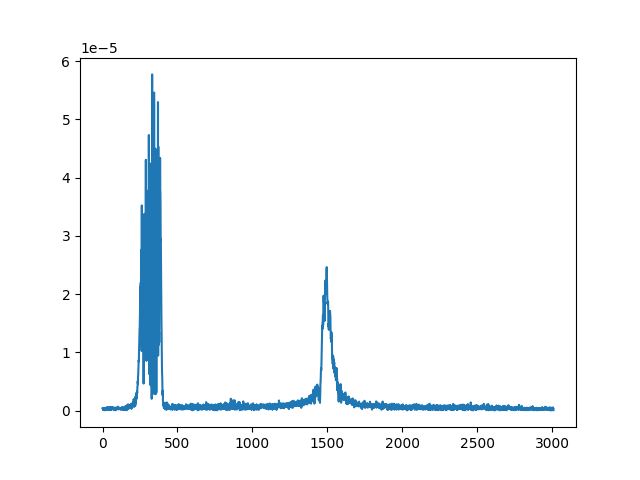

In [14]:
from pilottone.signal import to_hybrid_kspace

plt.figure()
plt.plot(np.abs(to_hybrid_kspace(data_cal[:,10,0])))

In [4]:
n_channels = data.shape[2]
sensing_coils = np.array(cfg['pilottone']['sensing_coils'], dtype=int)
mri_coils = np.arange(n_channels)
mri_coils = mri_coils[~np.isin(mri_coils, sensing_coils)]

coil_name = []

for clbl in hdr.acquisitionSystemInformation.coilLabel:
    coil_name.append(clbl.coilName)

coil_name = np.asarray(coil_name)
print(f'Coil names: {coil_name}')
print(f"Coils to be used as sniffers: {coil_name[sensing_coils]}")

f0 = hdr.experimentalConditions.H1resonanceFrequency_Hz
df = 1/(dt*data.shape[0])

t_acq_start = acq_list[0].acquisition_time_stamp*2.5e-3 # [2.5ms] -> [s]
t_acq_end = acq_list[-1].acquisition_time_stamp*2.5e-3
time_acq = np.linspace(t_acq_start, t_acq_end, n_acq) # Interpolate for TR, as TR will not be a multiple of time resolution.
time_pt = time_acq - t_acq_start
samp_time_pt = time_acq[1] - time_acq[0]

ksp_measured = data[:,:,mri_coils]
ksp_cal = data_cal[:,:,mri_coils]
ksp_sniffer  = data[:,:,sensing_coils]

## Process ECG waveform
ecg, _ = mrdhelper.waveforms_asarray(wf_list)
if ecg is not None:
    ecg_waveform = ecg['ecg_waveform']
    ecg_waveform = pt.check_waveform_polarity(ecg_waveform, 0.5)*ecg_waveform
    time_ecg = ecg['time_ecg'] - acq_list[0].acquisition_time_stamp*2.5e-3
    ecg_trigs = ecg['ecg_trigs']
else:
    print('No ECG waveform found, skipping the validation part.')
# plt.figure()
# plt.plot(time_ecg, ecg_waveform)
# plt.plot(time_ecg[ecg_trigs==1], ecg_waveform[ecg_trigs==1], '*')



Coil names: ['Body_6:1:B12' 'Body_6:1:B13' 'Body_6:1:B21' 'Body_6:1:B11'
 'Body_6:1:B23' 'Body_6:1:B22' 'Spine_18:1:S1P' 'Spine_18:1:S1S'
 'Spine_18:1:S2S' 'Spine_18:1:S2P' 'Spine_18:1:S1T' 'Spine_18:1:S2T'
 'Spine_18:1:S3P' 'Spine_18:1:S3S' 'Spine_18:1:S3T' 'Spine_18:1:S4T'
 'Spine_18:1:S4S' 'Spine_18:1:S4P']
Coils to be used as sniffers: []


/server/home/btasdelen/workspace/PyPilotTone/mrdhelper.py:125: UserWarning: No PT waveform found.
  warnings.warn('No PT waveform found.')


 ## PT correction

In [26]:

f_diff = f0 - f_pt

# pt_raw_cal, _ = extract_raw_pt(ksp_cal, kx, ky, n_unique_angles, acq_list[0], f_diff, df, dt, method='sine', freq_correction=True)
pt_raw1, ksp_ptsubbed1 = extract_raw_pt(ksp_measured, kx, ky, n_unique_angles, acq_list[0], f_diff, df, dt, method='sine', freq_correction=True)
# pt_raw2, ksp_ptsubbed2 = extract_raw_pt(ksp_measured, kx, ky, n_unique_angles, acq_list[0], f_diff, df, dt, method='sine', freq_correction=False)
# pt_raw3, ksp_ptsubbed3 = extract_raw_pt(ksp_measured, kx, ky, n_unique_angles, acq_list[0], f_diff, df, dt, method='wPCA', freq_correction=False)
# pt_raw4, ksp_ptsubbed4 = extract_raw_pt(ksp_measured, kx, ky, n_unique_angles, acq_list[0], f_diff, df, dt, method='wPCA', freq_correction=True)


/server/home/btasdelen/workspace/PyPilotTone/venv/lib/python3.10/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Text(0.5, 1.0, 'Motion')

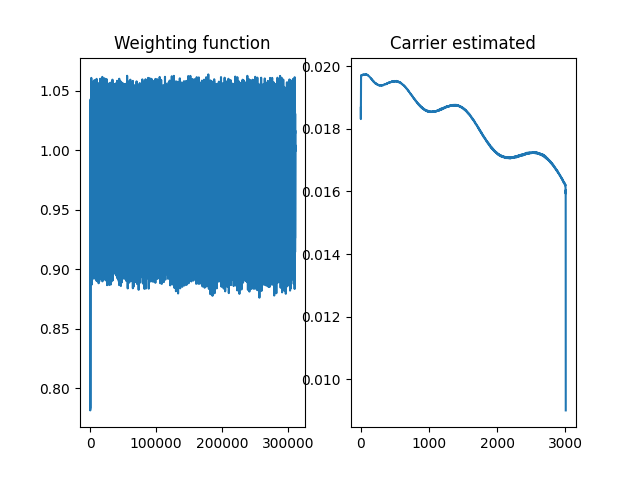

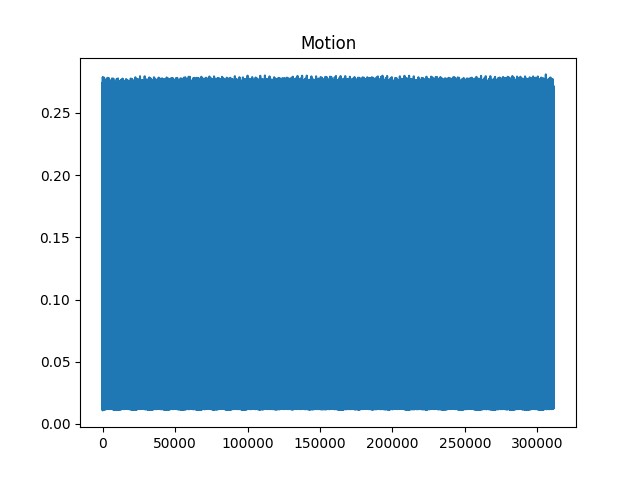

In [64]:
from scipy.sparse.linalg import svds
from pilottone.signal import cfftn

n_acq = ksp_measured.shape[1]
# ================================
# Demodulate any shifts
# ================================
phase_mod_rads = pt.calc_fovshift_phase(kx, ky, acq_list[0])
phase_mod_rads = [phase_mod_rads[:,ii%n_unique_angles] for ii in range(n_acq)]
phase_mod_rads = np.array(phase_mod_rads)[:, :].transpose()[:,:,None]

# Apply the negative of the phase
ksp_measured_ = ksp_measured*phase_mod_rads

fcorrmin = pt.find_freq_qifft(ksp_measured_[:,:,:], df, f_diff, 3e3, 4, (2))

# w_corr = np.exp(-2j*np.pi*np.arange(ksp_measured_.shape[0])[:,None]*dt*fcorrmin[None,:])
w_corr = np.ones(ksp_measured_.shape[0])[:,None]
w = np.median(np.abs(ksp_measured_.reshape(ksp_measured_.shape[0], -1)), axis=0)/np.mean(np.abs(ksp_measured_.reshape(ksp_measured_.shape[0], -1)), axis=0)
X = np.reshape(ksp_measured_*w_corr[:,:,None], (ksp_measured_.shape[0], -1))*w[None, :]
b, _,_ = svds(X, k=1)

plt.figure()
plt.subplot(1,2,1)
plt.plot(w)
plt.title('Weighting function')
plt.subplot(1,2,2)
plt.plot(np.abs(b))
plt.title('Carrier estimated')
m = np.conj(X.T) @ b

plt.figure()
plt.plot(np.abs(m))
plt.title('Motion')


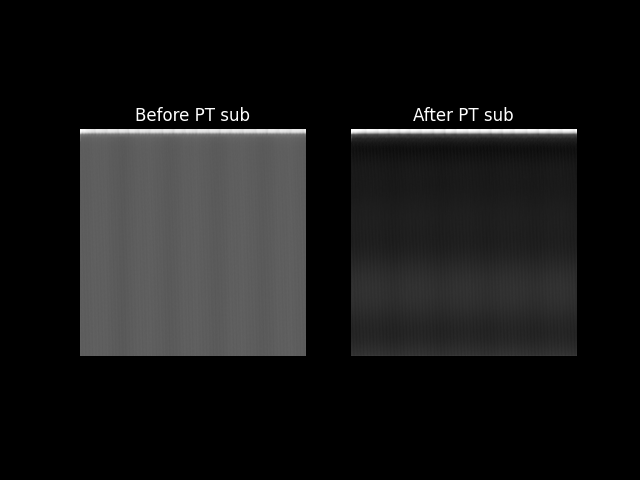

In [65]:

B = np.conj(X.T) @ b @ np.conj(b.T)
fcorrminB = pt.find_freq_qifft(np.reshape(np.conj(B.T), (ksp_measured_.shape[0], n_acq, -1))[:,:1,:], df, f_diff, 3e3, 4, (2))
ksp_sub, pt_sig_fit = pt.est_dtft(np.arange(0, ksp_measured_.shape[0])*dt, ksp_measured_, np.array([f_diff])-fcorrmin, np.abs(b[:,0])/np.mean(np.abs(b)))

ksp_sub1 = ksp_measured_ - np.reshape(np.conj(B.T), (ksp_measured_.shape[0], n_acq, -1))*np.conj(w_corr[:,:,None])

imsub = np.abs(ksp_sub[:,:3000, 0])
imksp = np.abs(ksp_measured_[:,:3000,0])
vmin = np.percentile(imsub, 1)
vmax = np.percentile(imsub, 99)
plt.figure()
plt.subplot(1,2,1)
plt.imshow(imksp, cmap='gray', label='Before PT sub', vmin=vmin, vmax=vmax)
plt.title('Before PT sub', color='white')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(imsub, cmap='gray', label='After PT sub', vmin=vmin, vmax=vmax)
plt.title('After PT sub', color='white')
plt.axis('off')
# black figure background
plt.gcf().set_facecolor('black')
plt.show()

In [6]:
print(f"Method sine: freq_correction true: {np.sum(np.abs(ksp_ptsubbed1[:,:3000,0]), axis=(0,1))}.")
print(f"Method sine: freq_correction false: {np.sum(np.abs(ksp_ptsubbed2[:,:3000,0]), axis=(0,1))}.")
print(f"Method wPCA: freq_correction false: {np.sum(np.abs(ksp_ptsubbed3[:,:3000,0]), axis=(0,1))}.")
print(f"Method wPCA: freq_correction true: {np.sum(np.abs(ksp_ptsubbed4[:,:3000,0]), axis=(0,1))}.")

Method sine: freq_correction true: 1298.0651148470372.
Method sine: freq_correction false: 1328.3907001118557.
Method wPCA: freq_correction false: 1321.1690837218355.
Method wPCA: freq_correction true: 1292.5900855880059.


In [66]:
print(f"Frequency correction: min={np.min(fcorrmin):.2f}, max={np.max(fcorrmin):.2f}, mean={np.mean(fcorrmin):.2f} Hz")
print(f"Frequency correction on B: min={np.min(fcorrminB):.2f}, max={np.max(fcorrminB):.2f}, mean={np.mean(fcorrminB):.2f} Hz")

Frequency correction: min=-47.51, max=37.71, mean=-5.61 Hz
Frequency correction on B: min=-6.11, max=-6.11, mean=-6.11 Hz


# Plot coils and raw PT

In [17]:
from matplotlib.patches import Circle
from typing import Tuple

def draw_coils(axs, coil_name, colors):

    all_coils = {
        'Body_6:1:B11': [+1, 5], 'Body_6:1:B12': [+0, 5], 'Body_6:1:B13': [-1, 5],
        'Body_6:1:B21': [+1, 4], 'Body_6:1:B22': [+0, 4], 'Body_6:1:B23': [-1, 4],
        'Spine_18:1:S1P': [+1, +2], 'Spine_18:1:S1S': [0, +2], 'Spine_18:1:S1T': [-1, +2],
        'Spine_18:1:S2P': [+1, +1], 'Spine_18:1:S2S': [0, +1], 'Spine_18:1:S2T': [-1, +1],
        'Spine_18:1:S3P': [+1,  0], 'Spine_18:1:S3S': [0,  0], 'Spine_18:1:S3T': [-1,  0],
        'Spine_18:1:S4P': [+1, -1], 'Spine_18:1:S4S': [0, -1], 'Spine_18:1:S4T': [-1, -1]
        }
    for i, coil in enumerate(coil_name):
        if coil in all_coils:
            # print(f'Coil: {coil}, Position: {all_coils[coil]}')
            # Create a circle for each coil position
            circle = Circle(all_coils[coil], radius=0.5, color=colors[i], fill=False, lw=2)
            axs.text(all_coils[coil][0], all_coils[coil][1], coil[-3:], fontsize=12, ha='center', va='center')
            axs.add_patch(circle)

    axs.text(2.3, 2, 'Patient\nLeft', fontsize=14, ha='center', va='center')
    axs.text(-2.3, 2, 'Patient\nRight', fontsize=14, ha='center', va='center')
    axs.axis('equal')
    axs.set_xlim(-2, 6)
    axs.set_ylim(-3, 2)
    axs.axis('off')

def plot_rawpt(pt_raw: np.ndarray, coil_name: np.ndarray, time_pt: np.ndarray, sort: bool=True, drawcoils: bool = True) -> Tuple[plt.Figure, np.ndarray]:
    if sort:
        Isort = np.argsort(coil_name)
    else:
        Isort = np.arange(pt_raw.shape[1])
    ptb = np.linspace(14e-4, -14e-4, pt_raw.shape[1])
    if drawcoils:
        f, axs = plt.subplots(1,2)
    else: 
        f, axs = plt.subplots(1,1)
    axs = np.atleast_1d(axs)
    f.set_size_inches(10, 10)
    lines = axs[0].plot(time_pt, ptb+pt_raw[:,Isort])
    for i, coil in enumerate((coil_name)[Isort]):
        axs[0].text(time_pt[-1]+10, ptb[i]+pt_raw[-1,i], coil[-3:], fontsize=10, ha='right', va='center', color=lines[i].get_color())
    axs[0].set_xlabel('Time [s]')

    axs[0].set_xlim(0, time_pt[-1]+10)
    axs[0].set_yticks([])
    default_colors = [line.get_color() for line in lines]
    if drawcoils:
        draw_coils(axs[1], (coil_name)[Isort], default_colors)
    plt.suptitle('Raw Pilot Tones and coil positions', fontsize=16)
    plt.tight_layout()
    return f, axs

Default colors used in the plot: ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


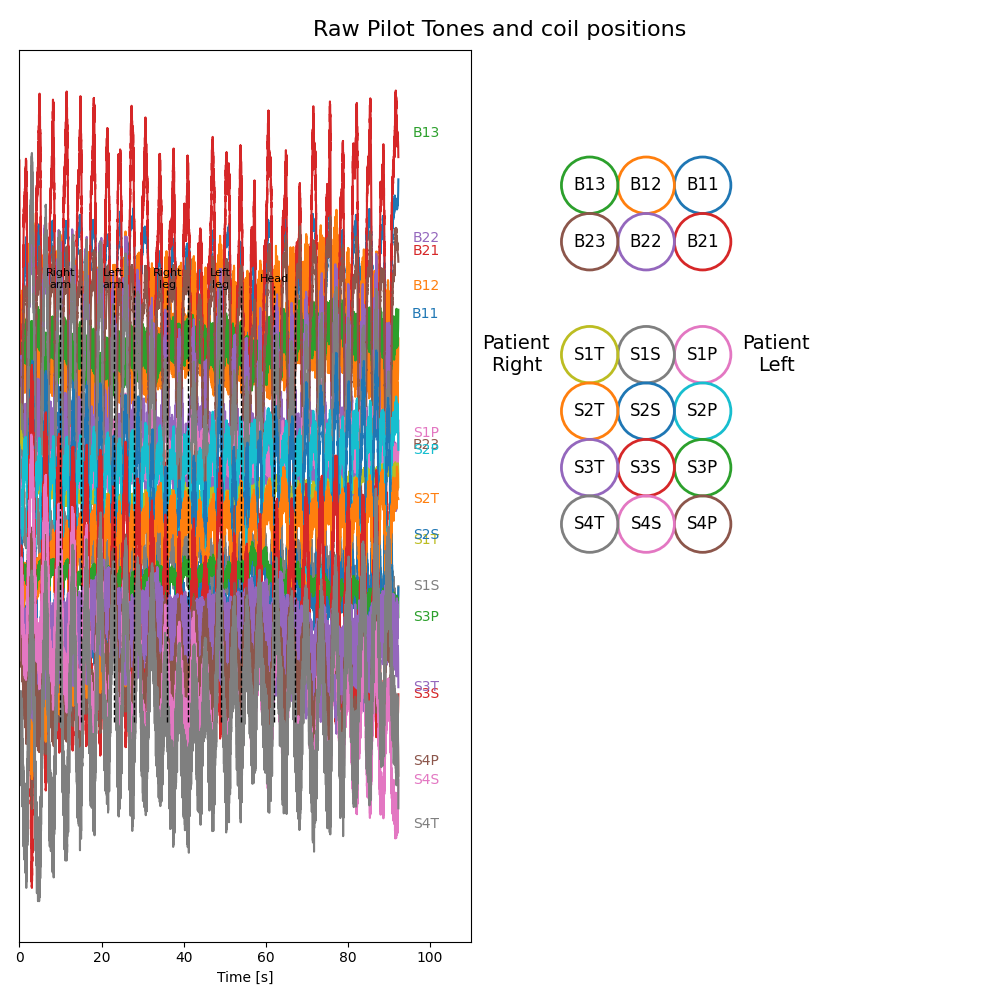

In [18]:
Isort = np.argsort(coil_name[mri_coils])
ptb = np.linspace(14e-4, -14e-4, pt_raw.shape[1])
pt_raw_filt = savgol_filter(pt_raw, 81, 3, axis=0)
f, axs = plt.subplots(1,2)
f.set_size_inches(10, 10)
lines = axs[0].plot(time_pt, ptb+pt_raw_filt[:,Isort])
for i, coil in enumerate((coil_name[mri_coils])[Isort]):
    axs[0].text(time_pt[-1]+10, ptb[i]+pt_raw_filt[-1,i], coil[-3:], fontsize=10, ha='right', va='center', color=lines[i].get_color())
# plt.legend(coil_name[mri_coils])
axs[0].set_xlabel('Time [s]')

# Movement sequence
# Right arm, left arm, right leg, left leg, head
axs[0].vlines([10, 15, 23, 28, 36, 41, 49, 54, 62, 67], ymin=ptb[-1]-1e-4, ymax=ptb[0]+1e-4, color='k', lw=1, linestyle='--')
axs[0].text(10, ptb[0]+1.5e-4, 'Right\narm', fontsize=8, ha='center', va='center')
axs[0].text(23, ptb[0]+1.5e-4, 'Left\narm', fontsize=8, ha='center', va='center')
axs[0].text(36, ptb[0]+1.5e-4, 'Right\nleg', fontsize=8, ha='center', va='center')
axs[0].text(49, ptb[0]+1.5e-4, 'Left\nleg', fontsize=8, ha='center', va='center')
axs[0].text(62, ptb[0]+1.5e-4, 'Head', fontsize=8, ha='center', va='center')
axs[0].set_xlim(0, 110)
axs[0].set_yticks([])
default_colors = [line.get_color() for line in lines]
print("Default colors used in the plot:", default_colors)
draw_coils(axs[1], (coil_name[mri_coils])[Isort], default_colors)
plt.suptitle('Raw Pilot Tones and coil positions', fontsize=16)
plt.tight_layout()
plt.show()

 ## QA and ECG PT Jitter

Using Body_6:1:B22 as the initial cardiac coil.
Number of channels selected for respiratory PT: 12
Number of channels selected for cardiac PT: 2
Rejection ratio for pt peaks is 0.93 percent.

Rejection ratio for derivative pt peaks is 0.93 percent.

Peak difference 286.7 ± 16.6
Derivative peak difference 147.3 ± 17.1
Number of ECG triggers: 108.
Number of PT triggers: 108.
Number of missed PT triggers: 0.
Number of extraneous PT triggers: 0.
Number of derivative PT triggers: 108.
Number of missed derivative PT triggers: 0.
Number of extraneous derivative PT triggers: 0.


/server/home/btasdelen/workspace/PyPilotTone/venv/lib/python3.10/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


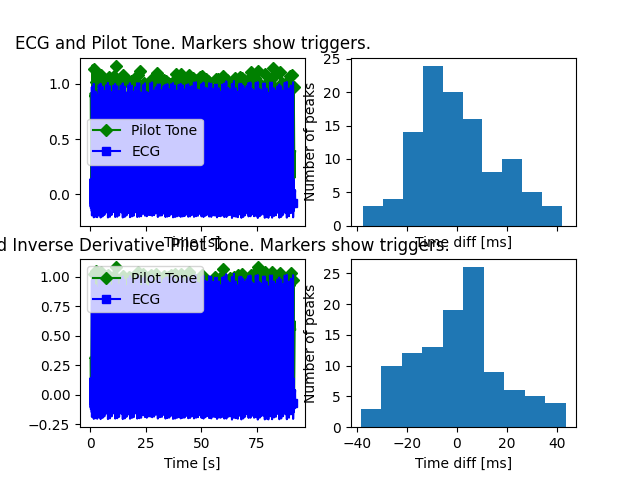

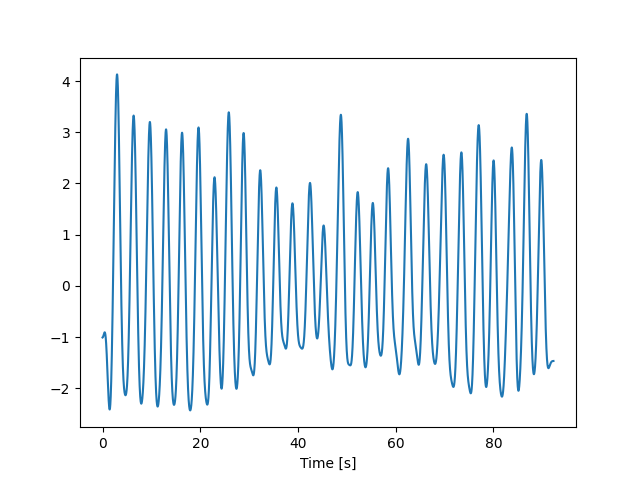

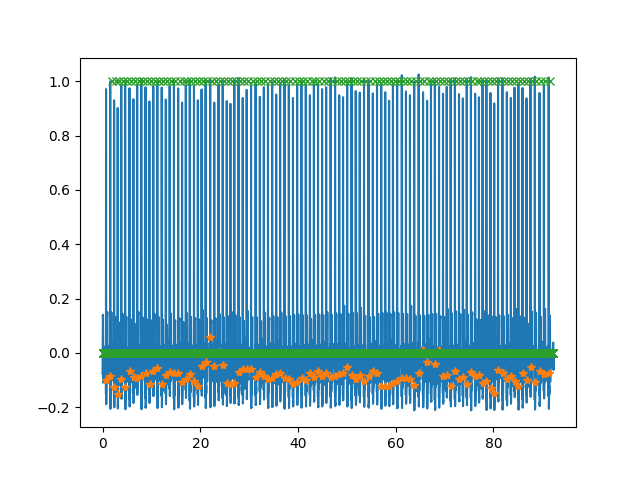

In [28]:
f_samp = 1/samp_time_pt # [Hz]
print(f"Using {cfg['pilottone']['cardiac']['initial_channel']} as the initial cardiac coil.")
pt_extract_params = {'golay_filter_len': cfg['pilottone']['golay_filter_len'],
                    'respiratory': {
                            'freq_start': cfg['pilottone']['respiratory']['freq_start'],
                            'freq_stop': cfg['pilottone']['respiratory']['freq_stop'],
                            'corr_threshold': cfg['pilottone']['respiratory']['corr_threshold'],
                            'corr_init_ch': cfg['pilottone']['respiratory']['initial_channel'],
                            'separation_method': cfg['pilottone']['respiratory']['separation_method'], # 'sobi', 'pca'
                    },
                    'cardiac': {
                                'freq_start': cfg['pilottone']['cardiac']['freq_start'],
                                'freq_stop': cfg['pilottone']['cardiac']['freq_stop'],
                                'corr_threshold': cfg['pilottone']['cardiac']['corr_threshold'],
                                'corr_init_ch': np.nonzero(coil_name == cfg['pilottone']['cardiac']['initial_channel'])[0][0],                           
                                'separation_method': cfg['pilottone']['cardiac']['separation_method'], # 'sobi', 'pca'

                    },
                    'debug': {
                        'selected_coils': cfg['pilottone']['debug']['selected_coils'],
                        'coil_legend': coil_name[mri_coils],
                        'show_plots': cfg['pilottone']['debug']['show_plots'],
                        'no_normalize': cfg['pilottone']['debug']['no_normalize'],
                    }
                }

sg_filter_len = 81

cal_select = (time_pt > 40) & (time_pt < 60)
# pt_respiratory, pt_cardiac = pt.extract_pilottone_navs(pt_raw, f_samp, pt_extract_params)
# Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw[cal_select,:], f_samp, pt_extract_params)
Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw_cal, f_samp, pt_extract_params)
pt_respiratory, pt_cardiac = pt.apply_pt_calib(pt_raw1, Vresp, accept_list_resp, Vcard.T, accept_list_cardiac, f_samp, pt_extract_params)

time_pt2 = time_pt

pt_cardiac = cfg['pilottone']['cardiac']['sign']*pt_cardiac
pt_cardiac[:20] = pt_cardiac[20]
pt_cardiac[-20:] = pt_cardiac[-20]
pt_cardiac -= np.percentile(pt_cardiac, 10)
pt_cardiac /= np.percentile(pt_cardiac, 95)

pt_cardiac_filtered = savgol_filter(pt_cardiac, sg_filter_len, 3, axis=0)
pt_cardiac_derivative = np.hstack((0, np.diff(pt_cardiac_filtered)/(time_pt[1] - time_pt[0])))
pt_cardiac_derivative[:20] = pt_cardiac_derivative[20]
pt_cardiac_derivative[-20:] = pt_cardiac_derivative[-20]
pt_cardiac_derivative -= np.percentile(pt_cardiac_derivative, 10)
pt_cardiac_derivative /= np.percentile(pt_cardiac_derivative, 98)

pt_cardiac_trigs = extract_triggers(time_pt2, pt_cardiac, skip_time=1, prominence=0.4, max_hr=160)
pt_derivative_trigs = extract_triggers(time_pt2, pt_cardiac_derivative, skip_time=1, prominence=0.5, max_hr=160)

if ecg is not None:
    _,_ = pt_ecg_jitter(time_pt2, pt_cardiac, pt_cardiac_derivative,
                        time_ecg, ecg_waveform, 
                        pt_cardiac_trigs=pt_cardiac_trigs, pt_derivative_trigs=pt_derivative_trigs, ecg_trigs=ecg_trigs, 
                        skip_time=1, show_outputs=cfg['pilottone']['show_outputs'])
    plt.figure()
    plt.plot(time_pt2, pt_respiratory, label='Respiratory')
    plt.xlabel('Time [s]')
    plt.show()
elif ecg is None and cfg['pilottone']['show_outputs']:
    fig, axs = plt.subplots(2,1, figsize=(10, 6), sharex=True)
    axs[0].plot(time_pt2, pt_cardiac, label='Cardiac')
    axs[0].plot(time_pt2, pt_cardiac_derivative, label='Cardiac Derivative')
    axs[0].plot(time_pt2[pt_cardiac_trigs==1], pt_cardiac[pt_cardiac_trigs==1], '*', label='Cardiac Triggers')
    axs[0].plot(time_pt2[pt_derivative_trigs==1], pt_cardiac_derivative[pt_derivative_trigs==1], '*', label='Cardiac Derivative Triggers')
    axs[0].set_title('Cardiac Triggers')
    axs[0].set_xlabel('Time [s]')
    axs[0].legend()
    axs[1].plot(time_pt2, pt_respiratory, label='Respiratory')
    axs[1].set_title('Respiratory')
    axs[1].set_xlabel('Time [s]')
    axs[1].legend()
    plt.show()



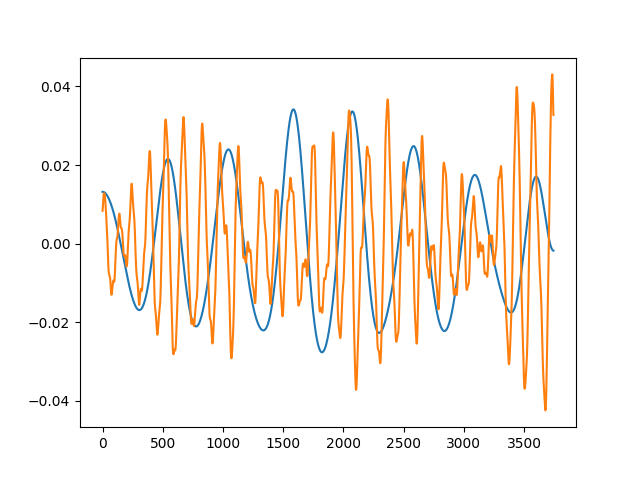

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


(<Figure size 1000x1000 with 2 Axes>,
 array([<Axes: xlabel='Time [s]'>, <Axes: >], dtype=object))

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


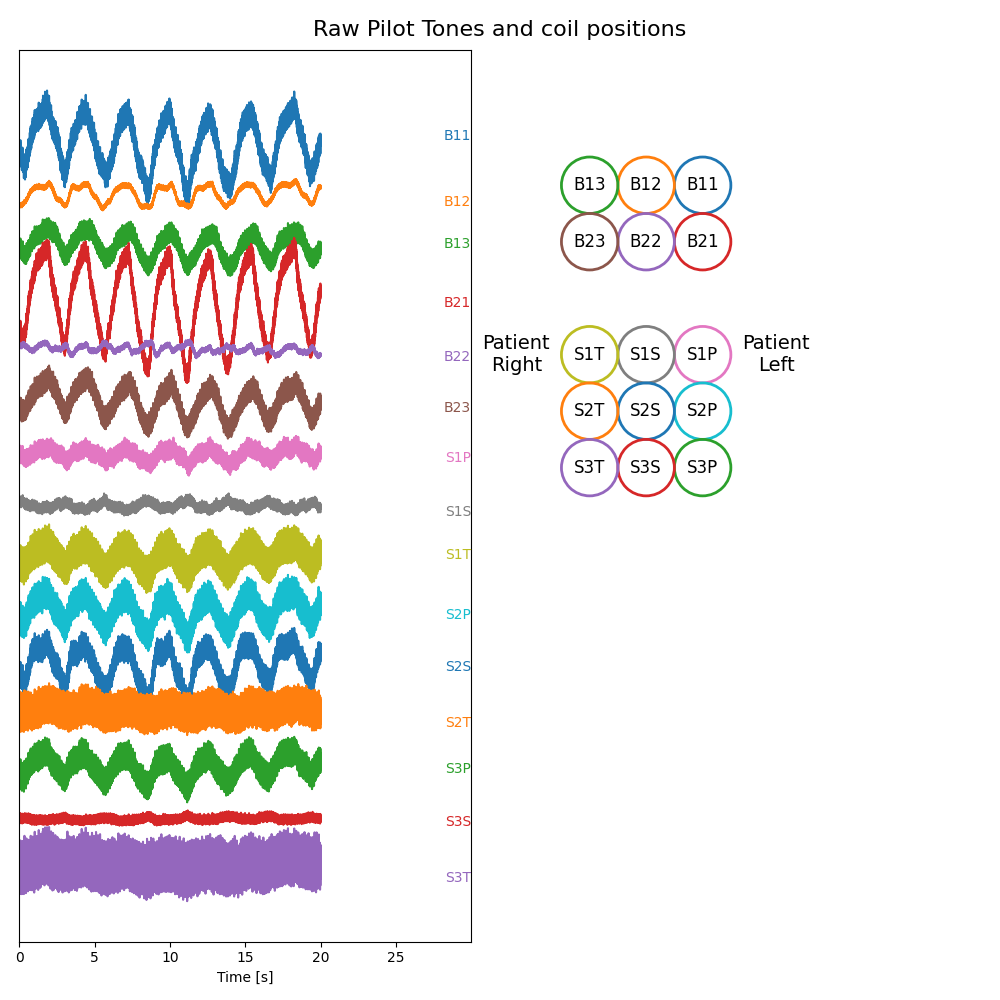

In [23]:
plt.figure()
plt.plot(pt_respiratory_cal, label='Respiratory Calibration')
plt.plot(pt_cardiac_cal, label='Cardiac Calibration')
plt.show()
pt_raw_cal = pt_raw[cal_select,:]
plot_rawpt(pt_raw_cal, coil_name[mri_coils], np.arange(pt_raw_cal.shape[0])*(time_pt[1]), sort=True, drawcoils=True)


 ## Save the waveforms into the original data

 Concat, and normalize pt waveforms.

In [23]:
import ctypes
from constants import PILOTTONE_WAVEFORM_ID
# %% [markdown]
# ## Save the waveforms into the original data
# Concat, and normalize pt waveforms.
dt_pt = (time_pt[1] - time_pt[0])
pt_wf_data = np.vstack((pt_respiratory, pt_cardiac, pt_cardiac_trigs, pt_cardiac_derivative, pt_derivative_trigs))
pt_wf_data = ((pt_wf_data/np.max(np.abs(pt_wf_data), axis=1, keepdims=True)*(2**31-1)) + 2**31).astype(np.uint32)

pt_wf = ismrmrd.waveform.Waveform.from_array(pt_wf_data)
pt_wf._head.sample_time_us = ctypes.c_float(dt_pt*1e6)
pt_wf._head.waveform_id = ctypes.c_uint16(PILOTTONE_WAVEFORM_ID)
pt_wf._head.time_stamp = acq_list[0].acquisition_time_stamp

# with ismrmrd.Dataset(ismrmrd_data_fullpath) as dset:
#     dset.append_waveform(pt_wf)

print('Done writing the waveform.')

Done writing the waveform.


In [24]:
# %% [markdown]
# # Save the PT subtracted k-space

from pathlib import Path
import copy
import pyfftw
from editer import autopick_sensing_coils

# Read the noise data in
print(f'Reading {ismrmrd_noise_fullpath}...')
with ismrmrd.Dataset(ismrmrd_noise_fullpath) as dset_noise:
    n_cal_acq = dset_noise.number_of_acquisitions()
    print(f'There are {n_cal_acq} acquisitions in the file. Reading...')

    cal_list = []
    for ii in range(n_cal_acq):
        cal_list.append(dset_noise.read_acquisition(ii))

noise_list = []

for cal_ in cal_list:
    if cal_.is_flag_set(ismrmrd.ACQ_IS_NOISE_MEASUREMENT):
        noise_list.append(cal_.data)

noise = np.transpose(np.asarray(noise_list), (1,0,2)).reshape((noise_list[0].shape[0], -1))[mri_coils,:]

if cfg['pilottone']['prewhiten']:
    from reconstruction.coils import apply_prewhitening, calculate_prewhitening

    print('Prewhitening the raw data...')
    dmtx = calculate_prewhitening(noise)

    ksp_ptsubbed = apply_prewhitening(np.transpose(ksp_ptsubbed4, (2,0,1)), dmtx).transpose((1,2,0))

if cfg['pilottone']['discard_badcoils']:
    mri_coils2, _ = autopick_sensing_coils(ksp_measured, f_emi=f_diff, bw_emi=100e3, bw_sig=200e3, f_samp=1/dt, n_sensing=5)
    ksp_ptsubbed = ksp_ptsubbed[:,:,mri_coils2]
    mri_coils = mri_coils[mri_coils2]
    
n_samp = ksp_ptsubbed.shape[0]

if remove_os:
    ksp_ptsubbed = pyfftw.byte_align(ksp_ptsubbed)

    keepOS = np.concatenate([np.arange(n_samp // 4), np.arange(n_samp * 3 // 4, n_samp)])
    ifft_ = pyfftw.builders.ifft(ksp_ptsubbed, n=n_samp, axis=0, threads=32, planner_effort='FFTW_ESTIMATE')
    ksp_ptsubbed = ifft_()

    fft_ = pyfftw.builders.fft(ksp_ptsubbed[keepOS, :, :], n=keepOS.shape[0], axis=0, threads=32, planner_effort='FFTW_ESTIMATE')
    ksp_ptsubbed = fft_()
    n_samp = n_samp // 2


output_dir_fullpath = os.path.join(data_dir, 'raw', 'h5_proc')
output_data_fullpath = os.path.join(output_dir_fullpath, f"{ismrmrd_data_fullpath.split('/')[-1][:-3]}_mdlsub.h5")
print('Saving to ' + output_data_fullpath)

Path.mkdir(Path(output_dir_fullpath), exist_ok=True)

# Update new parameters to XML header.
new_hdr = copy.deepcopy(hdr)
new_hdr.userParameters.userParameterString.append(ismrmrd.xsd.userParameterStringType('processing', 'ModelSubtraction'))
new_hdr.acquisitionSystemInformation.coilLabel = [hdr.acquisitionSystemInformation.coilLabel[ch_i] for ch_i in mri_coils]
new_hdr.acquisitionSystemInformation.receiverChannels = len(new_hdr.acquisitionSystemInformation.coilLabel)

# Copy and fix acquisition objects
new_acq_list = []

for acq_i, acq_ in enumerate(acq_list):
    new_head = copy.deepcopy(acq_.getHead())
    new_head.active_channels = len(new_hdr.acquisitionSystemInformation.coilLabel)
    new_head.available_channels = len(new_hdr.acquisitionSystemInformation.coilLabel)
    if remove_os:
        new_head.number_of_samples = ksp_ptsubbed.shape[0]
        new_head.center_sample = pre_discard//2

    new_acq_list.append(ismrmrd.Acquisition(head=new_head, data=np.ascontiguousarray(ksp_ptsubbed[:,acq_i,:].squeeze().T.astype(np.complex64))))

with ismrmrd.Dataset(output_data_fullpath, create_if_needed=True) as new_dset:
    for acq_ in new_acq_list:
        new_dset.append_acquisition(acq_)

    for wave_ in wf_list:
        new_dset.append_waveform(wave_)

    if cfg['saving']['save_pt_waveforms']:
        new_dset.append_waveform(pt_wf)

    new_dset.write_xml_header(ismrmrd.xsd.ToXML(new_hdr))

Reading /server/home/btasdelen/MRI_DATA/pilottone/vol1181_20250416/raw/noise/noise_meas_MID00227_FID14921_pulseq2D_fire_spiralga_200mV_24MHz.h5...
There are 1842 acquisitions in the file. Reading...
Prewhitening the raw data...
Saving to /server/home/btasdelen/MRI_DATA/pilottone/vol1181_20250416/raw/h5_proc/meas_MID00227_FID14921_pulseq2D_fire_spiralga_200mV_24MHz_mdlsub.h5


In [35]:
# Compare frames
m1 = np.load('output_recons/vol1181_20250416/m1.npy')
m2 = np.load('output_recons/vol1181_20250416/m2.npy')
m3 = np.load('output_recons/vol1181_20250416/m3.npy')
m4 = np.load('output_recons/vol1181_20250416/m4.npy')


In [ ]:
np.sum(m2-m1)

np.float64(-7147.750547147207)

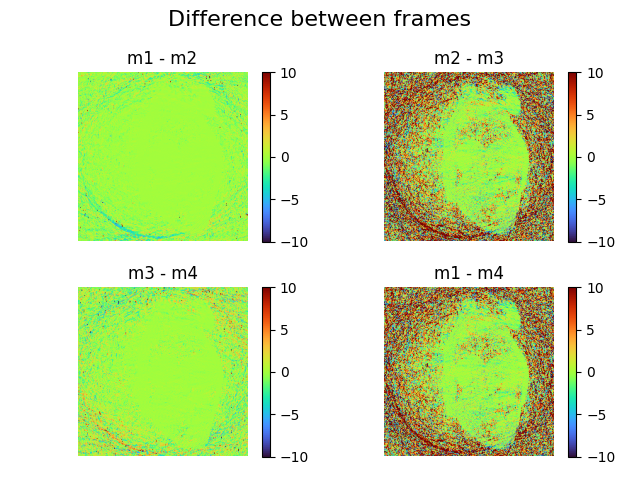

In [53]:
plt.figure()
plt.subplot(221)
plt.imshow(m1-m2, cmap='turbo', vmin=-10, vmax=10)
plt.title('m1 - m2')
plt.axis('off')
plt.colorbar()

plt.subplot(222)
plt.imshow(m2-m3, cmap='turbo', vmin=-10, vmax=10)
plt.title('m2 - m3')
plt.axis('off')
plt.colorbar()

plt.subplot(223)
plt.imshow(m3-m4, cmap='turbo', vmin=-10, vmax=10)
plt.title('m3 - m4')
plt.axis('off')
plt.colorbar()

plt.subplot(224)
plt.imshow(m1-m4, cmap='turbo', vmin=-10, vmax=10)
plt.title('m1 - m4')
plt.axis('off')
plt.colorbar()
plt.suptitle('Difference between frames', fontsize=16)
plt.tight_layout()
plt.show()